In [2]:
from sklearn.cluster import AgglomerativeClustering
import pandas as pd
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("NASDAQ-100/NASDAQ_100_Data_From_2010.csv", sep='\t')
print(df.columns.tolist())
print

['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Name']


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

# แปลง Adj Close ไปเป็น Daily_Return

In [4]:

df['Daily_Return'] = df.groupby('Name')['Adj Close'].pct_change()

df.pivot(index='Date', columns='Name', values='Adj Close')

Name,AAPL,ADBE,ADI,ADP,ADSK,AEP,ALGN,AMAT,AMD,AMGN,...,TSLA,TXN,VRSK,VRSN,VRTX,WBA,WDAY,XEL,XLNX,ZM
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-04,6.562591,37.090000,23.594395,28.139408,25.670000,22.072203,18.500000,11.452028,9.700000,45.008530,...,NaN,19.416849,29.356842,21.007998,44.240002,27.810350,NaN,14.072229,19.830650,NaN
2010-01-05,6.573935,37.700001,23.557144,27.988304,25.280001,21.819527,18.010000,11.363935,9.710000,44.618645,...,NaN,19.304874,29.553535,21.228777,42.779999,27.586676,NaN,13.905338,19.580618,NaN
2010-01-06,6.469369,37.619999,23.512444,27.922606,25.340000,22.040623,17.480000,11.339911,9.570000,44.283340,...,NaN,19.163038,29.937092,20.999506,42.029999,27.377913,NaN,13.932040,19.447794,NaN
2010-01-07,6.457407,36.889999,23.326195,27.909464,25.480000,22.230131,17.430000,11.219783,9.470000,43.877869,...,NaN,19.222761,29.887918,20.710794,41.500000,27.541943,NaN,13.871964,19.252451,NaN
2010-01-08,6.500339,36.689999,23.460297,27.870035,26.260000,22.495459,17.660000,11.652240,9.430000,44.267757,...,NaN,19.663202,29.504364,20.872135,40.669998,27.579229,NaN,13.878638,19.533739,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-09-03,154.300003,666.590027,162.440002,206.439804,288.750000,90.410004,721.500000,135.830002,109.919998,226.369995,...,733.570007,189.880005,205.080002,220.229996,198.050003,51.290001,277.739990,69.800003,155.960007,298.290009
2021-09-07,156.690002,661.390015,163.270004,201.313141,287.459991,88.910004,716.210022,136.490005,109.150002,221.339996,...,752.919983,189.460007,203.110001,220.250000,192.199997,51.000000,274.369995,67.900002,154.750000,299.959991
2021-09-08,155.110001,663.219971,163.669998,204.200012,289.559998,90.680000,729.919983,133.559998,106.169998,220.869995,...,753.869995,188.800003,206.339996,222.720001,191.369995,51.090000,272.200012,69.309998,153.309998,293.600006


### ลบแถวแรกของแต่ละหุ้นที่เป็น NaN ทิ้ง

In [5]:
df = df.dropna(subset=['Daily_Return'])
df[['Date', 'Name', 'Adj Close', 'Daily_Return']].head()

,Date,Name,Adj Close,Daily_Return
1,2010-01-05,AAPL,6.573935,0.001729
2,2010-01-06,AAPL,6.469369,-0.015906
3,2010-01-07,AAPL,6.457407,-0.001849
4,2010-01-08,AAPL,6.500339,0.006648
5,2010-01-11,AAPL,6.442997,-0.008821


# ทำความสะอาด (Clean) ข้อมูลหุ้นที่เพิ่งเข้าตลาดหลังปี 2010 เพื่อไม่ให้เกิดค่าว่าง (NaN) ที่กระทบต่อการคำนวณภาพรวม

### วิธีการทำ
หาหุ้นที่มีข้อมูลตั้งแต่วันแรกสุดของ datasets

In [6]:
first_date = df['Date'].min()
valid_stocks = df.groupby('Name')['Date'].min()
valid_stocks = valid_stocks[valid_stocks == first_date].index

df_clean = df[df['Name'].isin(valid_stocks)].copy()

print(f"เหลือหุ้น: {df_clean['Name'].nunique()} ตัว จาก {df['Name'].nunique()} ตัว")
print(df_clean['Name'].unique())
print(df_clean['Date'].unique().min())
print(df_clean['Date'].unique().max())

เหลือหุ้น: 82 ตัว จาก 102 ตัว
<StringArray>
[ 'AAPL',  'ADBE',   'ADI',   'ADP',  'ADSK',   'AEP',  'ALGN',  'AMAT',
   'AMD',  'AMGN',  'AMZN',  'ANSS',  'ASML',  'ATVI',  'AVGO',  'BIDU',
  'BIIB',  'BKNG',  'CDNS',  'CERN',  'CHKP', 'CMCSA',  'COST',  'CPRT',
  'CSCO',   'CSX',  'CTAS',  'CTSH',  'DLTR',  'DXCM',    'EA',  'EBAY',
   'EXC',  'FAST',  'FISV',  'GILD',  'GOOG', 'GOOGL',   'HON',  'IDXX',
  'ILMN',  'INCY',  'INTC',  'INTU',  'ISRG',   'KDP',  'KLAC',  'LRCX',
  'LULU',   'MAR',  'MCHP',  'MDLZ',  'MELI',  'MNST',  'MRVL',  'MSFT',
  'MTCH',    'MU',  'NFLX',  'NTES',  'NVDA',  'ORLY',  'PAYX',  'PCAR',
   'PEP',  'QCOM',  'REGN',  'ROST',  'SBUX',  'SGEN',  'SIRI',  'SNPS',
  'SWKS',  'TCOM',  'TMUS',   'TXN',  'VRSK',  'VRSN',  'VRTX',   'WBA',
   'XEL',  'XLNX']
Length: 82, dtype: str
2010-01-05
2021-09-10


# คำนวณ Correlation Matrix 
#### วิธีการทำ
1. แปลงเป็น wide format column = หุ้น, column = วันที่
2. คำนวณ correlation matrix เต็มรูปแบบ

In [7]:
wide_format = df.pivot(index='Date', columns='Name', values='Daily_Return')
corr_full = wide_format.corr()
print(corr_full)

Name      AAPL      ADBE       ADI       ADP      ADSK       AEP      ALGN  \
Name                                                                         
AAPL  1.000000  0.488553  0.503382  0.463292  0.462046  0.260121  0.356756   
ADBE  0.488553  1.000000  0.545003  0.537251  0.634392  0.278493  0.405513   
ADI   0.503382  0.545003  1.000000  0.562526  0.551503  0.260769  0.429992   
ADP   0.463292  0.537251  0.562526  1.000000  0.517277  0.460946  0.438226   
ADSK  0.462046  0.634392  0.551503  0.517277  1.000000  0.242835  0.424727   
...        ...       ...       ...       ...       ...       ...       ...   
WBA   0.289061  0.294845  0.330385  0.411845  0.309990  0.307584  0.246150   
WDAY  0.383238  0.571972  0.428108  0.401408  0.526177  0.126428  0.350667   
XEL   0.288065  0.323820  0.307120  0.494343  0.262117  0.842250  0.248549   
XLNX  0.425102  0.492949  0.693647  0.467161  0.497302  0.197254  0.348398   
ZM    0.170152  0.288472  0.067722 -0.044354  0.222399 -0.054315

3. แปลงเป็น metrix เป็นรายการคู่ๆ 

In [8]:
corr_full.index.name = 'Stock_1'
corr_full.columns.name = 'Stock_2'
corr_pairs = corr_full.unstack().reset_index()
corr_pairs.columns = ['Stock_2', 'Stock_1', 'Correlation']


4. ตัดคู่ที่จับตัวเอง และตัดคู่ซ้ำ

In [9]:
corr_pairs = corr_pairs[corr_pairs['Stock_1'] != corr_pairs['Stock_2']]
corr_pairs['pair_key'] = corr_pairs.apply(
    lambda x: tuple(sorted([x['Stock_1'], x['Stock_2']])), axis=1
)

corr_pairs = corr_pairs.drop_duplicates(subset='pair_key').drop(columns='pair_key')


5. หาคู่ที่สวนทางกันมากที่สุด

In [10]:
most_negative = corr_pairs.sort_values('Correlation').head(15)
print(most_negative)

     Stock_2 Stock_1  Correlation
4691     HON      ZM    -0.169107
4283    FOXA      ZM    -0.158001
5994     MAR    PTON    -0.147251
4181     FOX      ZM    -0.144680
9995     WBA      ZM    -0.137806
6017     MAR      ZM    -0.123068
7751    PCAR      ZM    -0.118111
8465    ROST      ZM    -0.101946
1835    BKNG      ZM    -0.088833
5609     KHC      ZM    -0.088674
4668     HON    PTON    -0.084348
2957     CSX      ZM    -0.082526
8038    PTON    ROST    -0.080969
8045    PTON    TCOM    -0.075090
1812    BKNG    PTON    -0.074356


## Visuallize Line chart

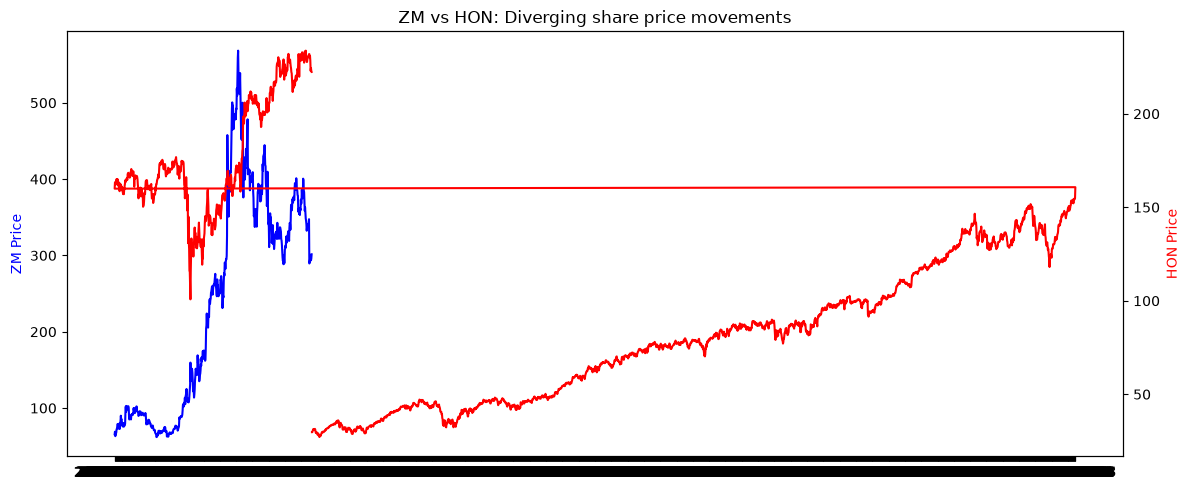

In [11]:
zm = df[df['Name']=='ZM'][['Date', 'Adj Close']].set_index('Date')
hon = df[df['Name']=='HON'][['Date', 'Adj Close']].set_index('Date')

fig, ax1 = plt.subplots(figsize=(12,5))
ax1.plot(zm.index, zm['Adj Close'], color='blue', label='ZM')
ax1.set_ylabel('ZM Price', color='blue')

ax2 = ax1.twinx()
ax2.plot(hon.index, hon['Adj Close'], color='red', label='HON')
ax2.set_ylabel('HON Price', color='red')

plt.title('ZM vs HON: Diverging share price movements')
plt.tight_layout()
plt.show()

# PCA 
#### วิธีทำ
1. เตรียมข้อมูล
2. เลือกเฉพาะหุ้นที่มีข้อมูลครบถ้วน
3. standardize
4. fit PCA
5. ดู explained variance
6. ดู loadings (น้ำหนักของแต่ละหุ้นในแต่ละ PC)

In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
# step 2 
earliest = df['Date'].min()
valid_stocks = df.groupby('Name')['Date'].min()
valid_stocks = valid_stocks[valid_stocks == earliest].index
df_clean = df[df['Name'].isin(valid_stocks)]
returns_wide = df_clean.pivot(index='Date', columns='Name', values='Daily_Return').dropna()

# step 3 
scaler = StandardScaler()
returns_scaled = scaler.fit_transform(returns_wide)

# step 4 
pca = PCA(n_components=10)
pca_scores = pca.fit_transform(returns_scaled)

# step 5 
print(pca.explained_variance_ratio_)

# step 6 
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(10)],
    index=returns_wide.columns
)
print(loadings)

[0.3885862  0.04225987 0.02957628 0.02232789 0.02143469 0.01547456
 0.01471381 0.01378624 0.01279975 0.01118935]
           PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
Name                                                                         
AAPL  0.117381 -0.050423  0.006198 -0.030790  0.099781 -0.064191  0.001403   
ADBE  0.128492 -0.046853  0.084624 -0.053270  0.168581  0.043393  0.039624   
ADI   0.139662 -0.121048 -0.158157 -0.074331 -0.118445 -0.018011  0.009851   
ADP   0.137756  0.142171 -0.040487  0.025433 -0.013365  0.026617  0.006019   
ADSK  0.127744 -0.079969  0.026946  0.045397  0.071960  0.079733 -0.018585   
...        ...       ...       ...       ...       ...       ...       ...   
VRSN  0.117452 -0.001541  0.064208 -0.014164  0.120787  0.081918  0.037508   
VRTX  0.073446 -0.012747  0.244813 -0.101540 -0.169754  0.040553 -0.018541   
WBA   0.084450  0.115238  0.009664  0.022864 -0.162535 -0.264926 -0.020284   
XEL   0.089143  0.329526 -0.0

## Graph Scree Plot

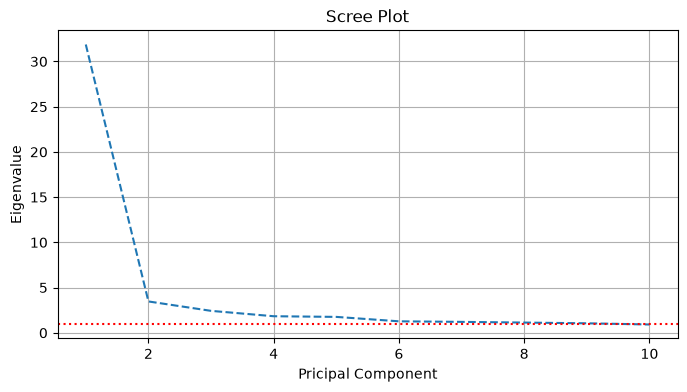

In [13]:
eig = pca.explained_variance_
plt.figure(figsize=(8, 4))
plt.plot(
    range(1, len(eig) + 1), eig, linestyle="--"
)
plt.title("Scree Plot")
plt.xlabel("Pricipal Component")
plt.ylabel("Eigenvalue")
plt.axhline(y=1, color="r", linestyle=":")
plt.grid(True)
plt.show()

## Graph Bar chart Loading ของ PC1
#### แนวคิด
Loading ของ PC1 คือน้ำหนักที่หุ้นแต่ละตัวมีต่อ Principal Component 1
ค่ายิ่งสูง แปลว่าหุ้นตัวนั้นไวต่อการเคลื่อนไหวของตลาดโดยรวมมาก
ค่ายิ่งต่ำ แปลว่าหุ้นตัวนั้นเคลื่อไหวค่อนข้างอิสระจากตลาด
```
Bar chart ของ loading ช่วยให้เห็นภาพว่า หุ้นตัวไหนคือ "core driver" ของตลาด และตัวไหนเป็น "outlier" ได้ในทีเดียว
```

#### วิธีทำ
1. ทำ PCA ก่อน
2. ดึง loading ของ PC1
3. เรียงลำดับค่าน้ำหนักเพื่อดูกราฟได้ง่ายขึ้น
4. เลือก Top 10 + bottom 10 เพื่อไม่ให้กราฟยาวเกินไป
5. พล็อต Bar chart

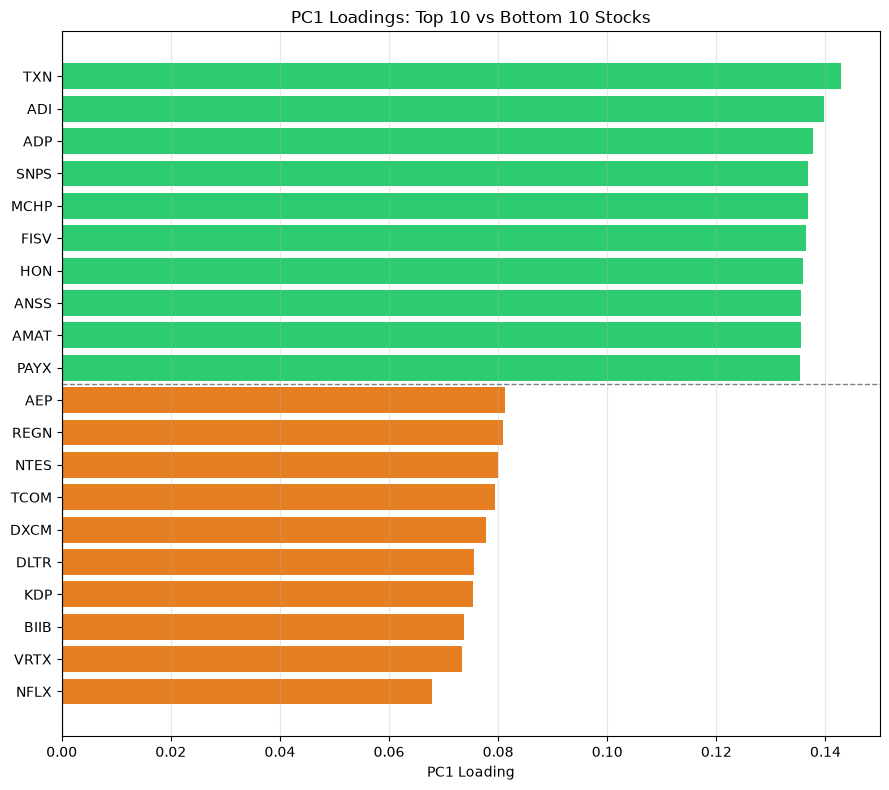

In [14]:
# step 2 and step 3 
pc1_loading = loadings['PC1'].sort_values(ascending=False)

# step 4 
top10 = pc1_loading.head(10)
bottom10 = pc1_loading.tail(10)
combined = pd.concat([top10, bottom10])

# step 5 
fig, ax = plt.subplots(figsize=(9, 8))
colors = ['#2ecc71']*10 + ['#e67e22']*10
ax.barh(combined.index, combined.values, color=colors)
ax.set_xlabel('PC1 Loading')
ax.set_title('PC1 Loadings: Top 10 vs Bottom 10 Stocks')
ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=0.8)
ax.axhline(9.5, color='gray', linestyle='--', linewidth=1)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('Barchart-loading.png', dpi=150)
plt.show()

# แบ่งกลุ่มด้วย K-Means และ Hierarchical: ให้โมเดลจัดกลุ่มหุ้นตามพฤติกรรมการเติบโตและความผันผวนที่คล้ายคลึงกัน
#### วิธีการทำ 
1. สร้าง Feature ที่แทนพฤติกรรมของแต่ละหุ้น
2. Standardize (ห้ามข้าม)
3. K-Means (ต้องกำหนด K)
4. Hierarchical (ไม่ต้องกำหนด K ล่วงหน้า)
5. Visualize

In [15]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# step 1
df['Daily_Return'] = df.groupby('Name')['Adj Close'].pct_change()

def max_drawdown(prices):
    cummax = prices.cummax()
    return ((prices - cummax) / cummax).min()

features = df.groupby('Name').agg(
    Mean_Return=('Daily_Return', 'mean'),
    Volatility=('Daily_Return', 'std'),
).reset_index()

mdd = df.groupby('Name')['Adj Close'].apply(max_drawdown).reset_index()
mdd.columns = ['Name', 'Max_Drawdown']
features = features.merge(mdd, on='Name')
features['Sharp_like'] = features['Mean_Return'] / features['Volatility']

In [16]:
# step 2
feature_cols = ['Mean_Return', 'Volatility', 'Max_Drawdown', 'Sharp_like']
X = StandardScaler().fit_transform(features[feature_cols])

In [17]:
# step 3 
kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
features['KMeans_Cluster'] = kmeans.fit_predict(X)

In [18]:
# step 4
Z = linkage(X, method='ward')
features['Hier_Cluster'] = fcluster(Z, t=4, criterion='maxclust')

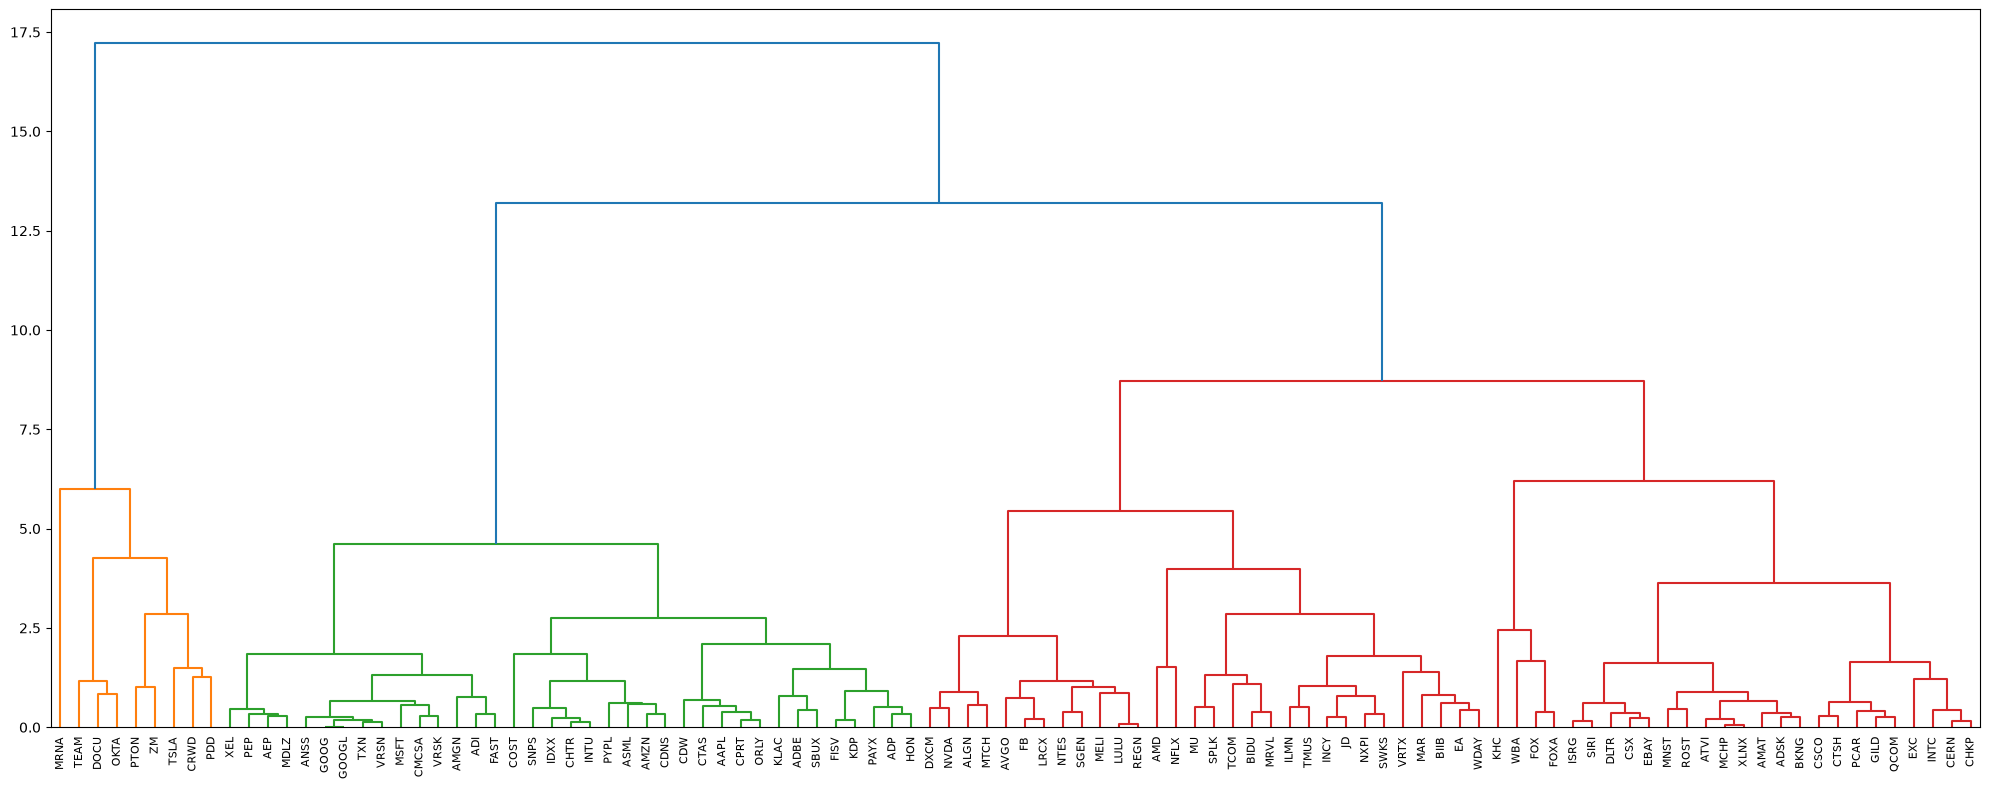

In [19]:
# step 5 
plt.figure(figsize=(20, 8))
dendrogram(Z, labels=features['Name'].values, orientation='top', leaf_font_size=8)
plt.tight_layout()
# plt.savefig('dendrogram_honrizontal.png', dpi=150)
plt.show()

# คัดกรองตัวแทนกลุ่ม: เมื่อได้คลัสเตอร์แล้ว เราจะเลือกหุ้นที่แข็งแกร่งที่สุดจากแต่ละกลุ่มมาเป็นตัวแทน
#### วิธีการเลือก

เลือกหุ้น 1 ตัวจากแต่ละ Cluster เพื่อเป็นตัวแทนพอร์ต โดยเลือกได้จากเกณฑ์ได้ 2 แบบ
1. Financial Criteria (เน้นผลตอบแทน/ความเสี่ยง): เลือกหุ้นที่มี Sharpe Ratio สูงที่สุด ในกลุ่มนั้น
2. Statistical Criteria (เน้นความสะท้อนพฤติกรรมกลุ่ม): เลือกหุ้นที่เป็น Medoid (จุดที่ Distance รวมต่ำสุดไปยังหุ้นอื่นในกลุ่มเดียวกัน)


#### วิธีการทำ
1. โหลดข้อมูลและ Pivot ราคา Adj Close
2. คำนวณ Daily Return และ Sharpe Ratio
3. จัดกลุ่ม Cluster (ตัวอย่าง K-Means บน Correlation Matrix)
4. รวมผลและคัดเลือกหุ้นที่มี Sharpe Ratio สูงสุดในแต่ละ Cluster

In [20]:
# step 2 
wide_format = df.pivot(index='Date', columns='Name', values='Daily_Return')
returns = wide_format.pct_change().dropna()
annual_ret = returns.mean() * 252
annual_vol = returns.std() * np.sqrt(252)
sharpe_ratio = (annual_ret - 0.02) / annual_vol

# step 3 
corr_metrix = returns.corr()
kmeans = KMeans(n_clusters=4, random_state=0, n_init=10)
clusters = kmeans.fit_predict(corr_metrix)

# step 4 
df_metrics = pd.DataFrame({'Cluster': clusters, 'Sharpe' : sharpe_ratio}, index=returns.columns)
representatives = df_metrics.loc[df_metrics.groupby('Cluster')['Sharpe'].idxmax()]
print(representatives)

      Cluster    Sharpe
Name                   
SPLK        0  0.754120
ASML        1  0.739443
AVGO        2  0.092836
ALGN        3 -0.275140


C:\Users\piyaw\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
C:\Users\piyaw\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


# หาจุดสมดุล (Optimal Weights): คำนวณหาสัดส่วนการถือครองของหุ้นแต่ละตัว
อาศัยหลักการ Modern Portfolio Theory (MPT) ของ Harry Markowitz โดยคำนวณหาค่า $w_i$ ที่กระจายน้ำหนักในหุ้นตัวแทนกลุ่ม เพื่อให้พอร์ตมีค่า Sharpe Ratio สูงสุด ภายใต้เงื่อนไขว่าผลรวมน้ำหนักต้องเท่ากับ 100% ($\sum w_i = 1$) และไม่มีการขายชอร์ต ($0 \le w_i \le 1$)

#### สมการพื้นฐานของการจัดพอร์ต
- ผลตอบแทนคาดหวังของพอร์ต: $E(R_p) = \mathbf{w}^T \mathbf{\mu} = \sum w_i E(R_i)$
- ความเสี่ยงของพอร์ต (Annualized Volatility): $\sigma_p = \sqrt{\mathbf{w}^T \mathbf{\Sigma} \mathbf{w}}$ (เมื่อ $\mathbf{\Sigma}$ คือ Covariance Matrix)
- ฟังก์ชันเป้าหมาย (Maximize Sharpe Ratio): $\text{Sharpe} = \frac{E(R_p) - R_f}{\sigma_p}$

#### วิธีการทำ
1. เตรียมข้อมูล Daily Returns และ Covariance Matrix
Assume 'pivoted' คือ DataFrame ราคา Adj Close ของหุ้นตัวแทน 5 ตัว
2. นิยาม Loss Function (Negative Sharpe Ratio เพื่อใช้กับ Optimizer)
3. กำหนดเงื่อนไข (Constraints & Bounds)
4. ประมวลผลหาค่า Optimal Weights ด้วยอัลกอริทึม SLSQP

In [21]:
from scipy.optimize import minimize

# step 1 
wide_format = df.pivot(index='Date', columns='Name', values='Daily_Return')
returns = wide_format.replace([np.inf, -np.inf], np.nan).dropna()

annual_returns = returns.mean() * 252
cov_metrix = returns.cov() * 252
risk_free_rate = 0.02

# step 2 
def negative_sharpe(weights, mean_returns, cov_mat, rf=0.02):
    p_return = np.sum(mean_returns * weights)
    p_std = np.sqrt(np.dot(weights.T, np.dot(cov_mat, weights)))
    return -(p_return - rf) / p_std


# step 3 
num_assets = len(annual_returns)
constraints = ({'type' : 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0, 1) for _ in range(num_assets))
initial_weights = num_assets * [1. / num_assets]

# step 4 
opt_result = minimize(
    negative_sharpe,
    initial_weights,
    args=(annual_returns, cov_metrix, risk_free_rate),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)
opt_weights = opt_result.x
print(opt_weights)

[1.53919954e-16 7.33549699e-16 1.97435922e-17 2.61468623e-16
 9.63036899e-17 2.49350889e-16 1.11577045e-01 1.84090513e-16
 2.49501785e-16 1.99249637e-16 4.34078797e-16 5.19808795e-16
 1.82388572e-02 5.78092156e-17 2.98263151e-17 1.24665843e-16
 2.07229500e-17 3.36954514e-16 1.63330039e-16 1.38929151e-16
 1.52291858e-17 2.37657139e-16 3.84741377e-02 2.64634971e-16
 3.59814582e-16 7.37374365e-16 1.41876802e-02 2.80853460e-16
 4.31418858e-17 3.42278764e-16 1.47296901e-16 7.75454106e-17
 3.47066896e-02 2.36097023e-02 5.50813559e-17 6.09198491e-16
 2.70215212e-16 4.04396103e-16 4.80181870e-16 7.18687621e-16
 2.83847802e-16 5.83831849e-16 1.62503483e-16 8.44389785e-03
 9.79572290e-16 2.69026945e-16 2.50540861e-16 1.61752989e-16
 1.00900574e-15 6.14412180e-16 5.80434676e-17 7.84617284e-17
 4.70984246e-16 4.45063778e-16 4.00740426e-16 1.03611056e-16
 0.00000000e+00 4.10636874e-17 5.38344609e-16 1.45872870e-17
 1.88184060e-16 2.09131931e-16 1.60948791e-16 2.60327608e-01
 1.50049844e-17 2.359330

### ทำตาราง Optimal Weights
#### วิธีการทำ
1. แมปผลลัพธ์ opt_weights กับรายชื่อหุ้นใน Dataframe
2. กรองเฉพาะหุ้นที่มีสัดส่วนมากกว่า 0.01% และจัดเรียงจากมากไปน้อย
3. ปรับฟอร์แมตตัวเลขทศนิยมให้ดูง่าย

In [22]:
# step 1 
portfolio_df = pd.DataFrame({
    'Stock': annual_returns.index,
    'Weight_%': opt_weights * 100
})

# step 2 
allocated = portfolio_df[portfolio_df['Weight_%'] > 0.01].sort_values(
    by='Weight_%', ascending=False
)

# step 3 
allocated['Weight_%'] = allocated['Weight_%'].map('{:.2f}%'.format)
print(allocated.to_string(index=False))

Stock Weight_%
 MRNA   26.03%
 TSLA   21.02%
 REGN   11.86%
 ALGN   11.16%
 PTON    9.14%
 CHTR    3.85%
 DOCU    3.47%
   ZM    3.29%
 NVDA    3.03%
 DXCM    2.36%
 ASML    1.82%
 CRWD    1.42%
 GOOG    0.84%
  PDD    0.70%
